For the updated parameters:  
Column 1: wavelength (µm)  
Column 2: pitch-to-wavelength ratio (unitless), chosen so that (Column 2) × (Column 1) = 0.4 µm (fixed physical pitch)  
Column 3: substrate dielectric constant, ε_sub  
Column 4: meta-atom dielectric constant, ε_atom  
Here ε = n² for both materials.  


Available datasets: ['neff', 'params', 'pattern', 'weight']

In [23]:
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

%matplotlib inline

from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
import torch.optim as optim

In [13]:
import h5py
import matplotlib.pyplot as plt

# Load the file
file_path = "CollectData_expanded2.h5"
with h5py.File(file_path, "r") as f:
    # Inspect keys
    print("Available datasets:", list(f.keys()))
    

Available datasets: ['neff', 'params', 'pattern', 'weight']
[9.6076256e+01 2.5516804e-02 4.4053122e-05 1.3211945e-03]


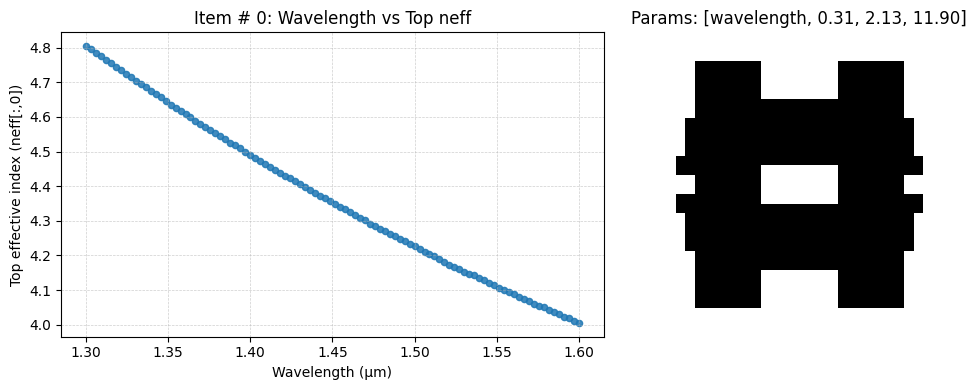

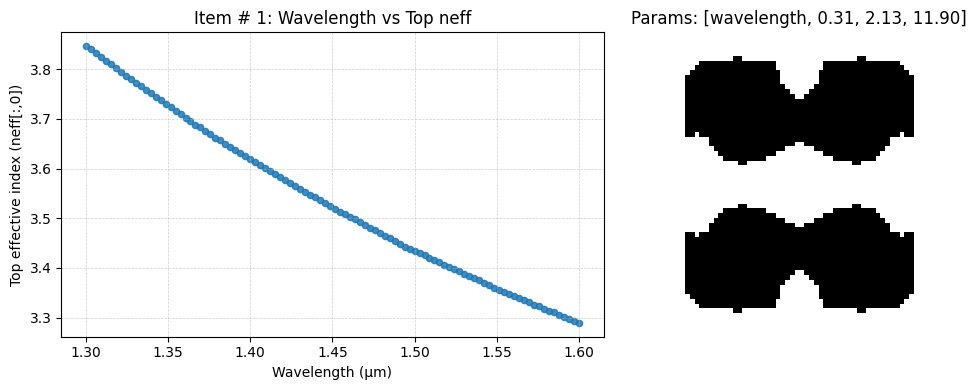

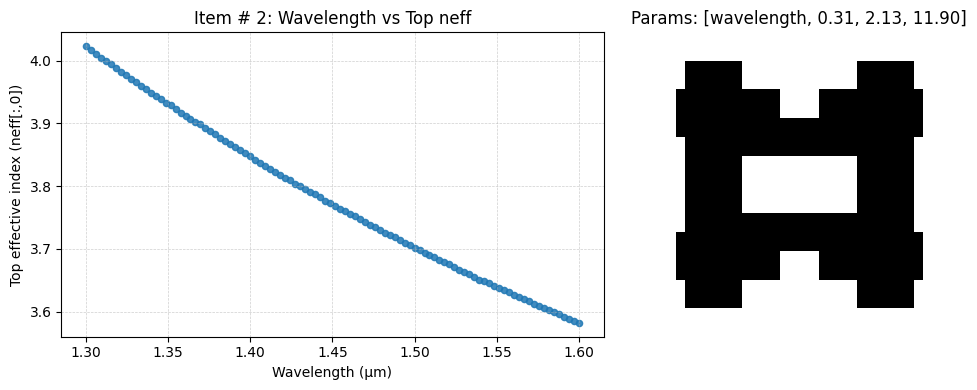

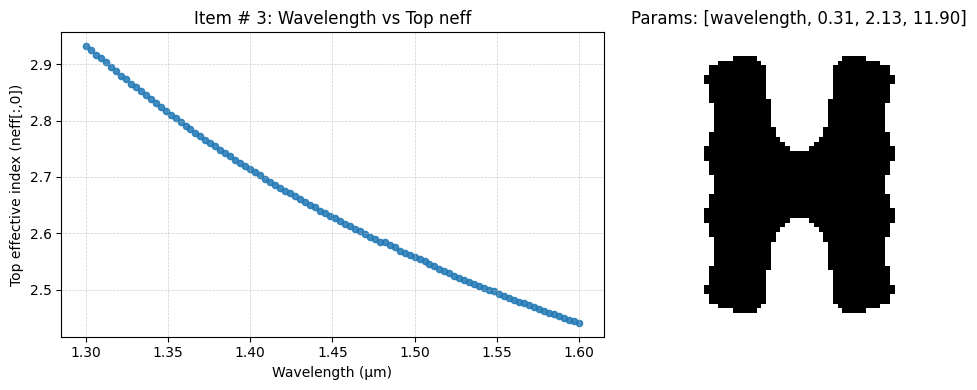

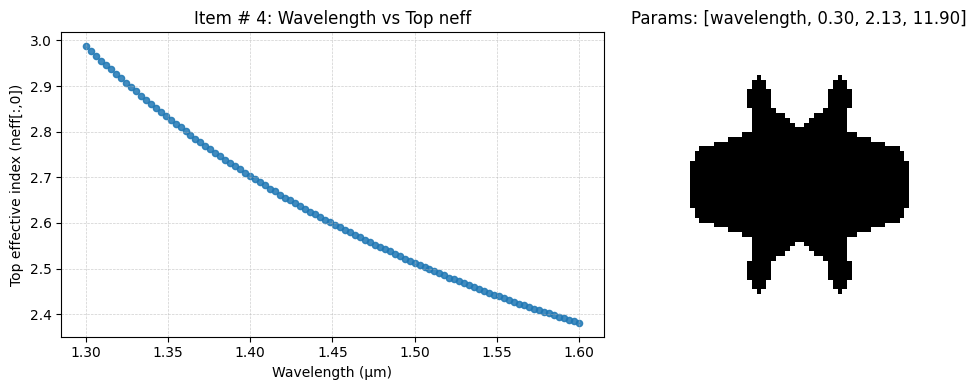

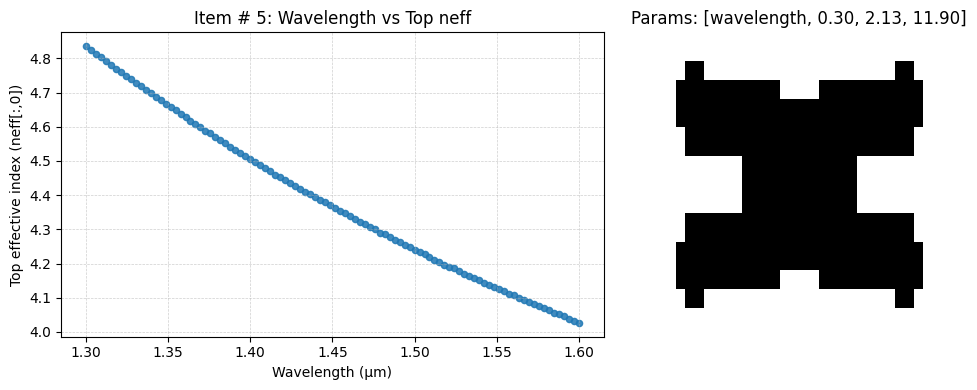

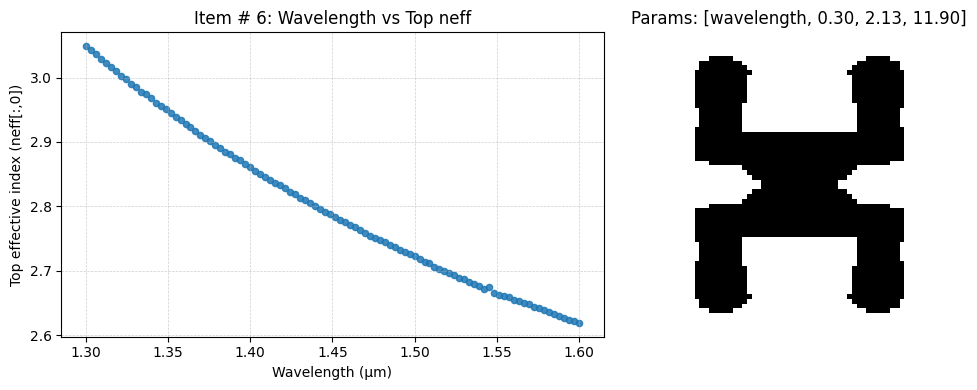

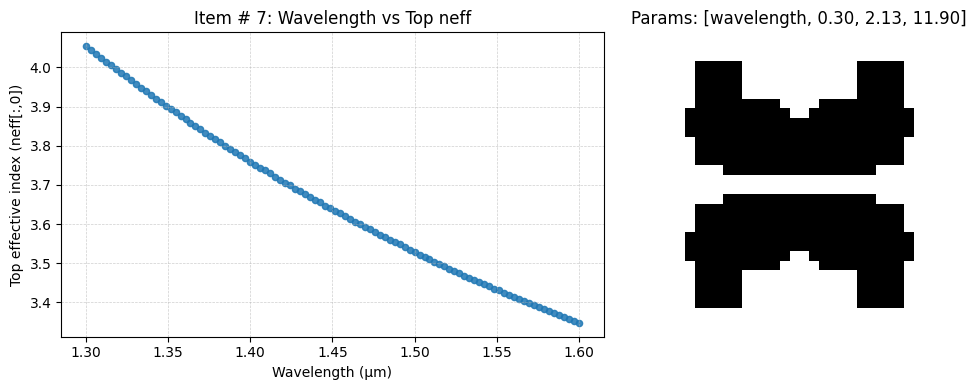

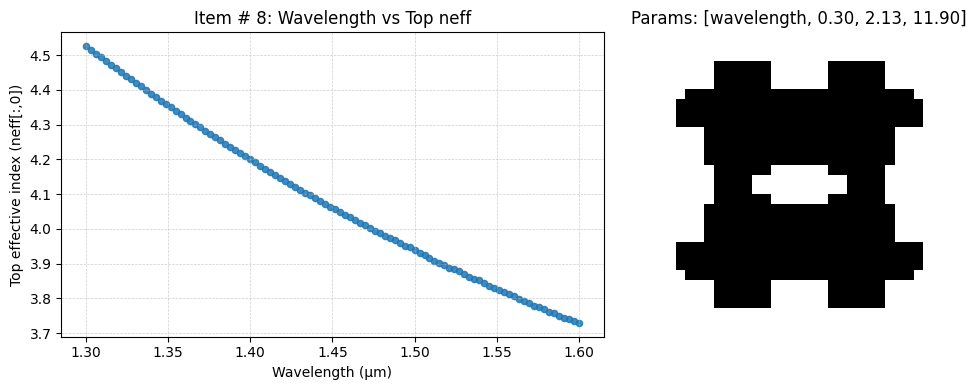

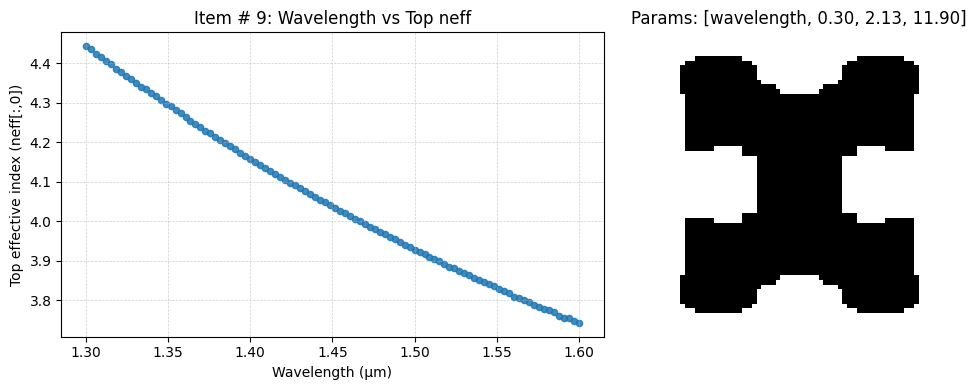

In [30]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(file_path, "r") as f:
    params = f["params"][:]   # shape (N, 4)
    neff   = f["neff"][:]     # shape (N, M) where M >= 1 (top neff is [:,0])
    pattern = f["pattern"][:] # shape (N, H, W) or similar
    weight = f["weight"][:]

# Your dataset structure: 10 items, each with 100 points, in contiguous blocks.
POINTS_PER_ITEM = 100
num_items = params.shape[0] // POINTS_PER_ITEM  # should be 10

for i in range(num_items):
    start = i * POINTS_PER_ITEM
    end   = start + POINTS_PER_ITEM

    # X and Y for the scatter
    wavelengths = params[start:end, 0]   # Column 0: wavelength (µm)
    top_neff    = neff[start:end, 0]     # First (top) effective index

    # Representative waveguide pattern for the item (first point in block)
    pattern_img = pattern[start]

    # Create the figure with two panels
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # Left: wavelength vs top neff
    ax = axes[0]
    ax.scatter(wavelengths, top_neff, s=20, alpha=0.85)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Top effective index (neff[:,0])")
    ax.set_title(f"Item # {i}: Wavelength vs Top neff")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # Right: waveguide pattern image
    ax_img = axes[1]
    im = ax_img.imshow(pattern_img, origin="upper", cmap="Greys")
    ax_img.set_title(f"Params: [wavelength, {params[i][1]:.2f}, {params[i][2]:.2f}, {params[i][3]:.2f}]")
    ax_img.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# CNN takes (waveguide[:32, :32], params)
class CombinedModeWeightNet(nn.Module):
    def __init__(self, mode_model, weight_model):
        super().__init__()
        self.mode_model = mode_model
        self.weight_model = weight_model

    def forward(self, x_img, x_cond):
        mode = self.mode_model(x_img, x_cond)   # [B, 1]
        weight = self.weight_model(x_img, x_cond)  # [B, 1]
        return torch.cat((mode, weight), dim=1)   # [B, 2]

from only_mode_only_weight_v3 import No_normal_modewieght_net

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mode0_model = No_normal_modewieght_net().to(device)
weight0_model = No_normal_modewieght_net().to(device)

mode0_model.load_state_dict(torch.load('models/only_first_mode_no_normalization_with_less_dropout.pth', map_location=torch.device(device)))
weight0_model.load_state_dict(torch.load('models/only_first_weight_no_normalization_with_less_dropout_100.pth', map_location=torch.device(device)))

cnn = CombinedModeWeightNet(mode0_model, weight0_model).to(device)
cnn.eval()

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch

POINTS_PER_ITEM = 100

# --- Optional: choose device (cpu if no cuda) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = cnn.to(device).eval()  # cnn is assumed to be already loaded

# --- Load data ---
with h5py.File(file_path, "r") as f:
    params = f["params"][:]    # shape (N, 4): [wavelength, pitch_ratio, eps_sub, eps_atom]
    neff   = f["neff"][:]      # not used for plotting, but handy for sanity checks
    pattern = f["pattern"][:]  # shape (N, H, W)
    
num_items = params.shape[0] // POINTS_PER_ITEM  # should be 10

# --- If you used normalization during training, define it here ---
def preprocess_wg(x_np):
    """
    x_np: (H, W) numpy array
    Return: torch tensor float32 (1, 1, 32, 32) after any required normalization.
    """
    # Crop/resize: here we assume at least 32x32 available; adjust if needed.
    x_np = x_np[:32, :32]
    x = torch.from_numpy(x_np).float()  # (32,32)
    # Example normalization (commented out — replace with your training-time transforms)
    # x = (x - x.mean()) / (x.std() + 1e-6)
    x = x.unsqueeze(0).unsqueeze(0)     # (1,1,32,32)
    return x

def preprocess_params(p_np):
    """
    p_np: (K, 4) numpy array for a block of K points
    Return: torch tensor float32 (K, 4) after any required normalization.
    """
    p = torch.from_numpy(p_np).float()
    # Example normalization (commented out — replace as needed)
    # p = (p - p.mean(dim=0, keepdim=True)) / (p.std(dim=0, keepdim=True) + 1e-6)
    return p

# --- Inference helper: run model for one item block of 100 points ---
@torch.no_grad()
def predict_top_neff_for_item(wg_img_np, params_block_np, batch_size=100):
    """
    wg_img_np: (H, W) numpy array (same waveguide for all 100 points)
    params_block_np: (100, 4) numpy array (varying wavelengths etc.)
    Returns: (100,) numpy array of predicted top neff
    """
    # Preprocess inputs
    wg_single = preprocess_wg(wg_img_np).to(device)     # (1,1,32,32)
    params_block = preprocess_params(params_block_np).to(device)  # (100,4)

    # Repeat the waveguide image across the batch
    wg_batch = wg_single.repeat(params_block.shape[0], 1, 1, 1)   # (100,1,32,32)

    # Forward pass (cnn should return (neff_pred, weight_pred))
    neff_pred, weight_pred = cnn(wg_batch, params_block)  # shapes: (100,1), (100,1) or similar
    # Squeeze to (100,)
    neff_top = neff_pred.squeeze(-1).detach().cpu().numpy()
    return neff_top

# --- Plotting loop: 10 figures, each with two panels ---
for i in range(num_items):
    start = i * POINTS_PER_ITEM
    end   = start + POINTS_PER_ITEM

    wavelengths = params[start:end, 0]      # (100,)
    params_block = params[start:end, :]     # (100,4)
    wg_img = pattern[start]                 # representative pattern for the item

    # Predict top neff using the cnn
    neff_top_pred = predict_top_neff_for_item(wg_img, params_block)  # (100,)

    # Figure with two panels
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4),
        gridspec_kw={"width_ratios": [3, 2]}
    )

    # Left: wavelength vs predicted top neff
    ax = axes[0]
    ax.scatter(wavelengths, neff_top_pred, s=20, alpha=0.85)
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Predicted top effective index (neff̂)")
    ax.set_title(f"Item # {i}: Wavelength vs Predicted neff")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # Right: waveguide pattern
    ax_img = axes[1]
    im = ax_img.imshow(wg_img, origin="upper", cmap="viridis")
    ax_img.set_title(f"Item # {i}: Waveguide pattern (idx {start})")
    ax_img.axis("off")

    plt.tight_layout()
    plt.show()
